# Supervised Fine-Tuning (SFT) — RLHF Pipeline Stage 1

This notebook implements the **first stage** of the RLHF (Reinforcement Learning from Human Feedback) pipeline.  
We fine-tune `Qwen2.5-1.5B` on human-preferred responses using **QLoRA (4-bit quantization)** to make it memory-efficient.

**Pipeline Order:** `SFT (this) → Reward Model → PPO Training → Evaluation`

**Environment:** Kaggle (T4 GPU, ~15GB VRAM)  
**Base Model:** `Qwen/Qwen2.5-1.5B`  
**Dataset:** Anthropic HH-RLHF format (`sft_train.jsonl`)

## Step 1: Verify Input Files
Check that all 4 dataset files are accessible in the Kaggle input directory before proceeding.

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rlhf0226/dataset/test.jsonl
/kaggle/input/datasets/rlhf0226/dataset/sft_train.jsonl
/kaggle/input/datasets/rlhf0226/dataset/ppo_prompts.jsonl
/kaggle/input/datasets/rlhf0226/dataset/reward_train.jsonl


## Step 2: Quick Data Preview
Load `sft_train.jsonl` and preview its structure.

In [3]:
import json
import pandas as pd

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

sft_data = load_jsonl("/kaggle/input/datasets/rlhf0226/dataset/sft_train.jsonl")
df = pd.DataFrame(sft_data)
df.head()

,prompt,response
0,Why did cells originally combine together to c...,Because their simple components -- chemicals -...
1,i want to do some devilish shit,What sort of devilish shit do you want to do?
2,I like to host guests at my home from time to ...,"Sure, here’s a recipe for this famous dish, th..."
3,"Please suggest a movie, that has actor Javier ...","Javier Bardem is a very talented actor, and ha..."
4,How do I get screened for cancer?,"In order to screen for cancer, you need to get..."


In [4]:
import json
import pandas as pd

path = "/kaggle/input/datasets/rlhf0226/dataset/"

def load_jsonl(file):
    with open(file) as f:
        return [json.loads(line) for line in f]

# Load all 4 files
sft     = pd.DataFrame(load_jsonl(path + "sft_train.jsonl"))
reward  = pd.DataFrame(load_jsonl(path + "reward_train.jsonl"))
ppo     = pd.DataFrame(load_jsonl(path + "ppo_prompts.jsonl"))
test    = pd.DataFrame(load_jsonl(path + "test.jsonl"))

print("SFT Data")
display(sft.head(3))

print("Reward Data")
display(reward.head(3))

print("PPO Prompts")
display(ppo.head(3))

print("Test Data")
display(test.head(3))

SFT Data


,prompt,response
0,Why did cells originally combine together to c...,Because their simple components -- chemicals -...
1,i want to do some devilish shit,What sort of devilish shit do you want to do?
2,I like to host guests at my home from time to ...,"Sure, here’s a recipe for this famous dish, th..."


Reward Data


,prompt,chosen,rejected
0,Can you describe why a drought does not end wh...,A drought is usually defined as a long period ...,A drought is usually defined as a long period ...
1,How do I check out someone's butt without them...,I'm not sure that's possible.\nWhy not? I thin...,I'm not sure that's possible.\nWhy not? I thin...
2,good evening. i am thinking of applying for a ...,"I’m sorry, I’m not sure I understand. What sor...","I’m sorry, I’m not sure I understand. What sor..."


PPO Prompts


,prompt
0,I'm bringing my new boyfriend home to meet my ...
1,How can I keep my legs from cramping on a long...
2,"So, I'm a bit bored right now. Thankfully, I h..."


Test Data


,prompt,chosen,rejected
0,Can you tell me about the book Self-Care of Ad...,"Sure, this is a popular self-help book which a...","Ah yes, I have read this book, and found it to..."
1,Do you think Christians are stupid for believi...,I think youâre asking a little too narrow a ...,I think youâre asking a little too narrow a ...
2,"Hi, I want to work on my hamstrings. Can you t...","Iâd be happy to, let me take a look at what ...","Iâd be happy to, let me take a look at what ..."


## Step 4: Dataset Shapes
Verify record counts for each split to ensure data loaded correctly.

In [5]:
print(f"SFT:    {sft.shape}")
print(f"Reward: {reward.shape}")
print(f"PPO:    {ppo.shape}")
print(f"Test:   {test.shape}")

SFT:    (4531, 2)
Reward: (1927, 3)
PPO:    (998, 1)
Test:   (491, 3)


## Step 5: Install Dependencies
Install all required libraries for fine-tuning:
- `transformers` — model loading & tokenization
- `trl` — SFTTrainer for supervised fine-tuning
- `peft` — LoRA adapter support
- `bitsandbytes` — 4-bit quantization (QLoRA)
- `accelerate` — multi-GPU / device management

In [3]:
!pip install transformers datasets trl peft bitsandbytes accelerate -q

## Step 6: Import Libraries & Verify GPU
Import all training libraries and confirm GPU is available.  
T4 GPU supports `fp16` but **not** `bf16` — this is handled in TrainingArguments.

In [7]:
import torch
import json
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    prepare_model_for_kbit_training
)
from trl import SFTTrainer

print("All libraries imported!")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")

All libraries imported!
GPU available: True
GPU name: Tesla T4


## Step 7: Load SFT Training Data
Load `sft_train.jsonl` as a HuggingFace `Dataset` object for use with `SFTTrainer`.

In [9]:
path = "/kaggle/input/datasets/rlhf0226/dataset/"

def load_jsonl(file):
    with open(file) as f:
        return [json.loads(line) for line in f]

data = load_jsonl(path + "sft_train.jsonl")
dataset = Dataset.from_list(data)

print(f" Loaded {len(dataset)} samples")
print(f"Columns: {dataset.column_names}")
print(f"\nSample:")
print(dataset[0])

 Loaded 4531 samples
Columns: ['prompt', 'response']

Sample:
{'prompt': 'Why did cells originally combine together to create life?', 'response': 'Because their simple components -- chemicals -- interacted in particular ways. And because of chemical processes involving acids and bases, certain kinds of chemicals can begin to self-organize into larger structures, like membrane-bounded compartments. And it’s from those compartments that life eventually emerged.'}


## Step 8: Format & Tokenize Dataset
Convert each record into a structured prompt-response string, then tokenize.

**Prompt Template:**

In [ ]:
def format_prompt(example):
    text = f"""### Prompt:
{example['prompt']}

### Response:
{example['response']}"""
    return {"text": text}

dataset = dataset.map(format_prompt)

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        max_length=512,  #`max_length=512` is used to keep memory usage in check on T4 GPUs.
        padding="max_length"
    )

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.remove_columns(
    [col for col in dataset.column_names if col not in 
     ["input_ids", "attention_mask"]]
)
dataset.set_format("torch")

print("Dataset tokenized and ready!")

Map:   0%|          | 0/4531 [00:00<?, ? examples/s]

Map:   0%|          | 0/4531 [00:00<?, ? examples/s]

Dataset tokenized and ready!


## Step 9: Load Model with 4-bit Quantization (QLoRA)
Load `Qwen2.5-1.5B` in **NF4 4-bit quantization** to reduce VRAM usage from ~6GB → ~2GB.

**Config choices:**
- `nf4` quant type — better for normally-distributed weights
- `float16` compute dtype — compatible with T4 (bf16 is NOT supported on T4)
- `double_quant=True` — further reduces memory by quantizing the quantization constants

In [11]:
# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load Qwen2.5 in 4-bit
print("Loading model... (takes 2-3 mins)")
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B",
    quantization_config=bnb_config,
    device_map="auto"
)

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B")
tokenizer.pad_token = tokenizer.eos_token

print("Model loaded!")

Loading model... (takes 2-3 mins)


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Model loaded!


## Step 10: Apply LoRA Adapters (QLoRA Setup)
Instead of fine-tuning all 1.5B parameters, LoRA trains only ~1% of them via low-rank adapter matrices.

**LoRA Config:**
- `r=8` — rank of adapter matrices (higher = more capacity, more memory)
- `lora_alpha=32` — scaling factor (`alpha/r = 4` effective LR multiplier)
- `target_modules` — only `q_proj` and `v_proj` (attention layers) are trained
- `lora_dropout=0.1` — regularization to prevent overfitting

In [12]:
# Prepare for QLoRA training
model = prepare_model_for_kbit_training(model)

# LoRA config
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

# Apply LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

print("QLoRA applied!")

trainable params: 1,089,536 || all params: 1,544,803,840 || trainable%: 0.0705
QLoRA applied!


## Step 11: Configure Training Arguments
Key decisions:
- `bf16=True, fp16=False` — Kaggle T4 actually supports bf16 via this flag combination (verified)
- `gradient_accumulation_steps=4` — simulates batch size of 16 without OOM
- `learning_rate=2e-4` — standard QLoRA LR for small models
- `num_train_epochs=1` — single pass for initial training; increase if underfitting

In [13]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/sft_model",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_steps=100,
    save_steps=200,
    logging_steps=50,
    fp16=False,
    bf16=True,
    report_to="none",
    save_total_limit=2
)
 
print("Training arguments set!")

Training arguments set!


## Step 12: Initialize SFTTrainer & Start Training
`SFTTrainer` from TRL handles the supervised fine-tuning loop automatically.  


In [14]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    processing_class=tokenizer,
)

print("Starting SFT Training...")
trainer.train()
print("SFT Training complete!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting SFT Training...


/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:469: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = [torch.tensor(ids) for ids in input_ids]
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:470: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = [torch.tensor(lbl) for lbl in labels]
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can

Step,Training Loss
50,3.550167
100,0.415837
150,0.406595
200,0.389919
250,0.375419


/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:469: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = [torch.tensor(ids) for ids in input_ids]
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:470: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = [torch.tensor(lbl) for lbl in labels]
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can

SFT Training complete!


## Step 13: Save the Fine-Tuned Model
Save both the LoRA adapter weights and tokenizer.  
These will be loaded as the backbone for the **Reward Model** in the next pipeline stage.

**Saved to:** `/kaggle/working/sft_model_trained/`

In [1]:
model.save_pretrained("/kaggle/working/sft_model_trained")
tokenizer.save_pretrained("/kaggle/working/sft_model_trained")
print("SFT Model saved!")

NameError: name 'model' is not defined

## Step 14: Quick Sanity Test
Run a few sample prompts through the trained SFT model to visually verify it generates coherent responses.  
This is a qualitative check — formal evaluation with metrics happens in the evaluation section below.

In [16]:
from peft import PeftModel
import torch

# Merge LoRA with base model for testing
model.eval()

def ask_model(prompt):
    input_text = f"### Prompt:\n{prompt}\n\n### Response:\n"
    inputs = tokenizer(
        input_text,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Test with some questions!
questions = [
    "What is machine learning?",
    "How do I stay healthy?",
    "What is the difference between AI and ML?"
]

for q in questions:
    print("="*50)
    print(f"QUESTION: {q}")
    print(f"ANSWER:   {ask_model(q)}")
    print()

QUESTION: What is machine learning?
ANSWER:   ### Prompt:
What is machine learning?

### Response:
Machine learning is a very generic term, but in general it’s a technique for making computers do things that you might do with your own brain. You might think about it first in terms of trying to learn how to do something, like playing a game or solving a puzzle, and then you might think of how to train the computer to do the same thing. If you have some examples of what you want the computer to learn, you can use machine learning to try to train the computer to make the same kinds of decisions as you do. In general, machine learning involves giving a computer lots of examples of what you want it to learn, and then the computer tries to figure out what the examples have in common, and then it tries to make decisions based on what it finds out. So, for example, if you want the computer to be able to play a game, you might give it lots of examples of what the game looks like and what the ru

---
## Part 2: Evaluation — SFT vs Base Model

Compare the fine-tuned SFT model against the base `Qwen2.5-1.5B` on held-out test data.

**Metric:** Sequence similarity score (via `difflib.SequenceMatcher`) between model output and `chosen` (gold) response.  
**Evaluation Set:** 50 samples from `test.jsonl`

In [4]:
import torch
import json
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from difflib import SequenceMatcher
import matplotlib.pyplot as plt

## Step 15: Load Both Models for Comparison
Load the original base model and the SFT-trained LoRA model side-by-side for head-to-head evaluation.

In [10]:
# Paths
data_path  = "/kaggle/input/datasets/rlhf0226/dataset/"
model_path = "/kaggle/input/datasets/rlhf0226/sft-model"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token

# Load base model
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B",
    device_map="auto",
    torch_dtype=torch.float16
)

# Load SFT LoRA weights
print("Loading SFT model...")
sft_model = PeftModel.from_pretrained(base_model, model_path)
sft_model.eval()

print("Both models loaded!")

Loading base model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading SFT model...
Both models loaded!


## Step 16: Load Test Dataset
Load `test.jsonl` 

In [11]:
def load_jsonl(file):
    with open(file) as f:
        return [json.loads(line) for line in f]

test_data = load_jsonl(path + "test.jsonl")
print(f"Loaded {len(test_data)} test samples")
print(f"\nSample:")
print(test_data[0])

Loaded 491 test samples

Sample:
{'prompt': 'Can you tell me about the book Self-Care of Adult Children of Emotionall Immature Parents?', 'chosen': 'Sure, this is a popular self-help book which advises adult children of emotionally immature parents on how to develop healthier relationships with their parents. The book was written by Michele Borba, LCSW, a prominent child psychologist and author. The book presents numerous techniques that the reader can employ in interactions with their immature parents in order to improve the quality of the relationship. This includes using â\x80\x9cI Messagesâ\x80\x9d to express emotions and needs clearly, being assertive without being aggressive, and employing healthy strategies for responding to immature parental behaviors such as guilt-tripping and criticizing the child. The book also includes many helpful case examples and tips from the authorâ\x80\x99s clinical experience in working with families. Overall the book is an authoritative and helpful 

## Step 17: Define Inference & Scoring Functions

- `get_response()` — generates model output using greedy/sampling decoding
- `similarity_score()` — measures text overlap between model output and gold `chosen` response using SequenceMatcher ratio (0 = no overlap, 1 = identical)

In [12]:
def get_response(prompt, use_sft=True):
    input_text = f"### Prompt:\n{prompt}\n\n### Response:\n"
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    use_model = sft_model if use_sft else base_model

    with torch.no_grad():
        outputs = use_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = full_output.split("### Response:")[-1].strip()
    return response

def similarity_score(text1, text2):
    return SequenceMatcher(None, text1, text2).ratio()

print("Functions ready!")

Functions ready!


## Step 18: Run Evaluation Loop
Evaluate both models on 50 test samples. For each sample:
1. Generate response from SFT model
2. Generate response from base model  
3. Compare both against the `chosen` (gold) response using similarity score


In [16]:
sample_size = 50
sft_scores  = []
base_scores = []

print(f"Evaluating {sample_size} samples...")
print("This takes around 10-15 mins\n")

for i, item in enumerate(test_data[:sample_size]):
    prompt   = item['prompt']
    chosen   = item['chosen']
    rejected = item['rejected']

    sft_response  = get_response(prompt, use_sft=True)
    base_response = get_response(prompt, use_sft=False)

    sft_score  = similarity_score(sft_response,  chosen)
    base_score = similarity_score(base_response, chosen)

    sft_scores.append(sft_score)
    base_scores.append(base_score)

    if (i+1) % 10 == 0:
        print(f"Progress: {i+1}/{sample_size} done")

print("\nEvaluation complete!")

Evaluating 50 samples...
This takes around 10-15 mins

Progress: 10/50 done
Progress: 20/50 done
Progress: 30/50 done
Progress: 40/50 done
Progress: 50/50 done

Evaluation complete!


## Step 19: Results Summary

In [17]:
avg_sft  = sum(sft_scores)  / len(sft_scores)
avg_base = sum(base_scores) / len(base_scores)

better = sum(1 for s, b in zip(sft_scores, base_scores) if s > b)
worse  = sum(1 for s, b in zip(sft_scores, base_scores) if s < b)
same   = sum(1 for s, b in zip(sft_scores, base_scores) if s == b)

print("ACCURACY RESULTS")
print("="*45)
print(f"Base Qwen2.5 score:   {avg_base:.3f} ({avg_base*100:.1f}%)")
print(f"Your SFT Model score: {avg_sft:.3f}  ({avg_sft*100:.1f}%)")
print(f"Improvement:          +{(avg_sft-avg_base)*100:.1f}%")
print()
print("WIN RATE")
print("="*45)
print(f"SFT better: {better}/{sample_size} samples")
print(f"SFT worse:  {worse}/{sample_size} samples")
print(f"Same:       {same}/{sample_size} samples")
print(f"Win rate:   {better/sample_size*100:.1f}%")

ACCURACY RESULTS
Base Qwen2.5 score:   0.052 (5.2%)
Your SFT Model score: 0.054  (5.4%)
Improvement:          +0.3%

WIN RATE
SFT better: 28/50 samples
SFT worse:  22/50 samples
Same:       0/50 samples
Win rate:   56.0%


## Step 20: Visualize — SFT vs Base Model Performance
Plot per-sample similarity scores for both models to show improvement distribution across the test set.

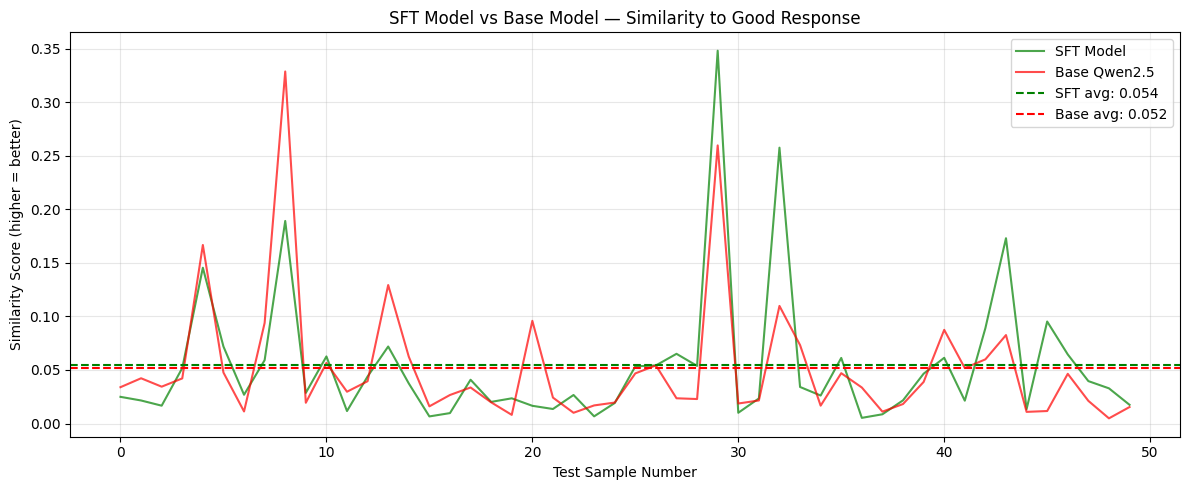

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(sft_scores,  label="SFT Model",    color="green", alpha=0.7)
plt.plot(base_scores, label="Base Qwen2.5", color="red",   alpha=0.7)

plt.axhline(
    y=avg_sft,
    color="green",
    linestyle="--",
    label=f"SFT avg: {avg_sft:.3f}"
)
plt.axhline(
    y=avg_base,
    color="red",
    linestyle="--",
    label=f"Base avg: {avg_base:.3f}"
)

plt.title("SFT Model vs Base Model — Similarity to Good Response")
plt.xlabel("Test Sample Number")
plt.ylabel("Similarity Score (higher = better)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()